# Problema 1: Diseño de Filtros Digitales

**Estudiante:** Kent Lin Chan (20202132)

**Curso:** IEE352 — Procesamiento Digital de Señales (2026-1)

**Python:** 3.14.2

---
Se desea diseñar filtros pasabajos para aplicaciones de radar. El sistema de recepción de señales de radar basado en un dispositivo SDR (Software Defined Radio) adquiere datos con una velocidad de muestreo de $F_s = 100$ MHz. La señal digitalizada pasa primero por un demodulador para llevar la señal a banda base, luego por un filtro pasabajos y finalmente por un decimador para reducir la tasa de muestreo a 1 MHz. La frecuencia de corte del filtro a diseñar debe ser de $F_c = 500$ kHz para respetar el criterio de Nyquist.

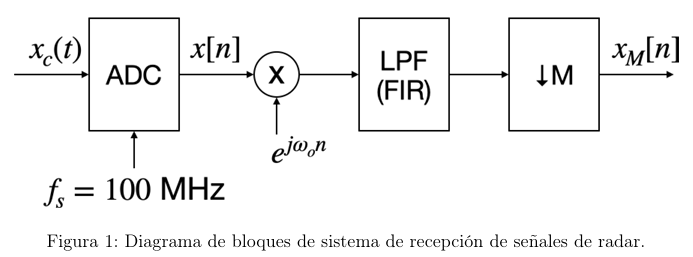

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import kaiser
from scipy.signal import remez

# Estilo global de figuras
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110


## Parámetros del Sistema
- Frecuencia de muestreo: $F_s = 100$ MHz
- Frecuencia de muestreo (post-decimación): $F_s' = 1$ MHz
- Frecuencia de corte: $F_c = 500$ kHz
- Atenuación mínima en banda de rechazo: $A_{stop} = 80$ dB
- Ancho de banda de transición máximo: $0.10 \times F_s' = 100$ kHz

**Definición de bandas:**

- Banda de paso: $0 \leq f \leq F_p = 450$ kHz
- Banda de transición: $450 \text{ kHz} < f < 550$ kHz
- Banda de rechazo: $f \geq F_{stop} = 550$ kHz

In [2]:
# --- Parámetros comunes ---
Fs = 100e6            # Frecuencia de muestreo: 100 MHz
Fs_dec = 1e6          # Frecuencia de muestreo post-decimación: 1 MHz
Fc = 500e3            # Frecuencia de corte: 500 kHz
A_stop = 80           # Atenuación mínima en stopband: 80 dB
transicion_ancho = 0.10 * Fs_dec   # 100 kHz (10% de Fs')
Fp = Fc - transicion_ancho / 2     # 450 kHz
Fstop = Fc + transicion_ancho / 2  # 550 kHz

print(f"Fs        = {Fs/1e6} MHz")
print(f"Fs_dec    = {Fs_dec/1e6} MHz")
print(f"Fc        = {Fc/1e3} kHz")
print(f"Fp        = {Fp/1e3} kHz")
print(f"Fstop     = {Fstop/1e3} kHz")
print(f"Δf        = {transicion_ancho/1e3} kHz")
print(f"A_stop    = {A_stop} dB")


Fs        = 100.0 MHz
Fs_dec    = 1.0 MHz
Fc        = 500.0 kHz
Fp        = 450.0 kHz
Fstop     = 550.0 kHz
Δf        = 100.0 kHz
A_stop    = 80 dB


---

# Parte 1: Diseño de Filtro FIR con Ventana Kaiser

## Fundamentos del método

La técnica de enventanado consiste en truncar la respuesta impulsional infinita de un filtro ideal multiplicándola por una ventana finita. La elección de la ventana determina el compromiso entre la selectividad espectral (ancho de la banda de transición) y la atenuación en la banda de rechazo.

La **ventana Kaiser** se distingue porque permite controlar directamente la atenuación deseada en la banda de rechazo mediante un único parámetro $\beta$, sin necesidad de iteración. Para $A_{stop} > 50$ dB, la fórmula de Kaiser es:

Para aplicaciones de radar se prefieren filtros **FIR** sobre **IIR** porque:

1. **Fase lineal exacta** en la banda de paso (Tipo I, simetría par).
2. **Estabilidad garantizada** por construcción.
3. **Predictibilidad** de la respuesta (sin dependencia de polos).

## 1.1 Cálculo de parámetros


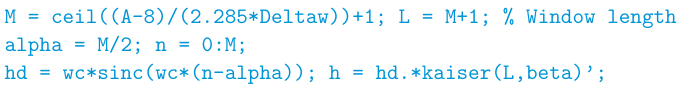

## Cálculo de beta
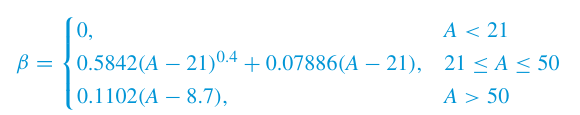

In [3]:
# Parámetro β de Kaiser (Manolakis & Ingle, Cap. 10)
if A_stop > 50:
    beta = 0.1102 * (A_stop - 8.7)
elif A_stop >= 21:
    beta = 0.5842 * (A_stop - 21) ** 0.4 + 0.07886 * (A_stop - 21)
else:
    beta = 0.0

# Ancho de transición normalizado
delta_f = transicion_ancho / Fs
delta_w = 2 * np.pi * delta_f  # rad/muestra

# Longitud del filtro (fórmula de Kaiser)
M_aprox = (A_stop - 8) / (2.285 * delta_w)
M = int(np.ceil(M_aprox)) + 1
L = M + 1
alpha = M / 2

print(f"Parámetro beta de Kaiser: {beta:.4f}")
print(f"Ancho de transición (Δf): {transicion_ancho/1e3:.2f} kHz")
print(f"Δω = {delta_w:.6f} rad/muestra")
print(f"M (semi-longitud): {M}")
print(f"L (longitud total): {L}")
print(f"Centro α = M/2 = {alpha}")


Parámetro beta de Kaiser: 7.8573
Ancho de transición (Δf): 100.00 kHz
Δω = 0.006283 rad/muestra
M (semi-longitud): 5016
L (longitud total): 5017
Centro α = M/2 = 2508.0


## 1.2 Diseño del FIR pasa-bajos con ventana Kaiser

In [4]:
# Frecuencia de corte normalizada (respecto a Nyquist)
fc_norm = Fc / (Fs / 2)
wc = np.pi * fc_norm  # rad/muestra

# Índice n para la respuesta al impulso (n = 0:M)
n = np.arange(M + 1)

# Respuesta al impulso del filtro ideal pasa-bajos
hd = (wc / np.pi) * np.sinc(wc * (n - alpha) / np.pi)

# Ventana de Kaiser
ventana_kaiser = kaiser(L, beta)

# Coeficientes del FIR: ideal × ventana
b = hd * ventana_kaiser

print(f"Frecuencia de corte normalizada (wc): {wc:.4f} rad/muestra")
print(f"Coeficientes del filtro (primeros 10):")
print(b[:10])


Frecuencia de corte normalizada (wc): 0.0314 rad/muestra
Coeficientes del filtro (primeros 10):
[-8.43564058e-08 -7.49381121e-08 -6.51859388e-08 -5.51052419e-08
 -4.47019285e-08 -3.39824583e-08 -2.29538441e-08 -1.16236519e-08
 -1.83951246e-22  1.19084427e-08]


In [5]:
# Verificar simetría y tipo del filtro FIR
is_symmetric = np.allclose(b, b[::-1])
is_antisymmetric = np.allclose(b, -b[::-1])

print(f"¿Simetría par? {is_symmetric}")
print(f"¿Simetría impar? {is_antisymmetric}")

N = len(b)
if is_symmetric and N % 2 == 1:
    tipo = "Tipo I (N impar, simetría par)"
elif is_symmetric and N % 2 == 0:
    tipo = "Tipo II (N par, simetría par)"
elif is_antisymmetric and N % 2 == 1:
    tipo = "Tipo III (N impar, simetría impar)"
elif is_antisymmetric and N % 2 == 0:
    tipo = "Tipo IV (N par, simetría impar)"
else:
    tipo = "No es FIR de fase lineal estándar"

print(f"Tipo de filtro: {tipo}")
print(f"Número total de coeficientes: {N}")


¿Simetría par? True
¿Simetría impar? False
Tipo de filtro: Tipo I (N impar, simetría par)
Número total de coeficientes: 5017


## 1.3 Gráfico de los coeficientes del filtro

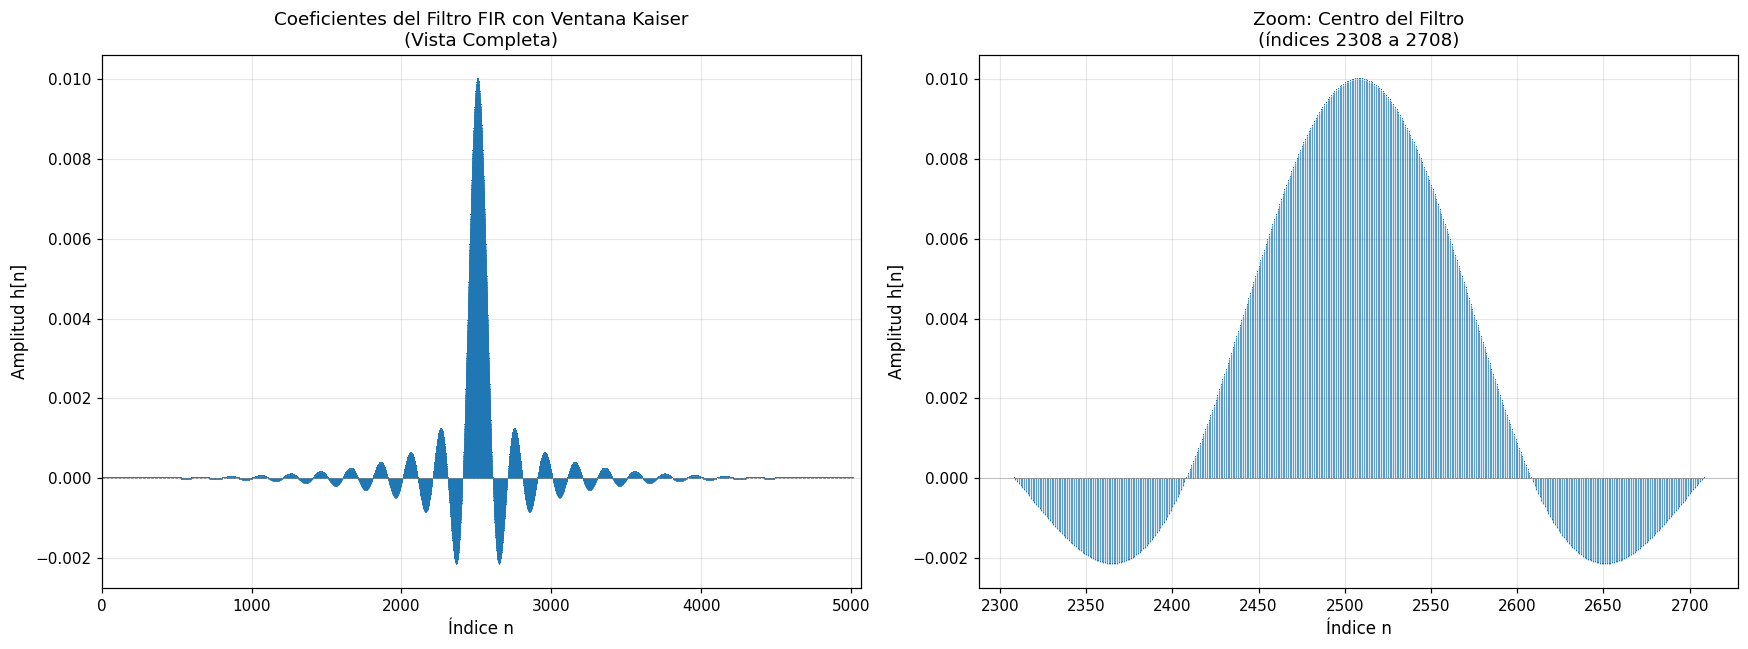

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Vista completa
markerline, stemlines, baseline = ax1.stem(n, b, linefmt='C0-', markerfmt='C0,')
plt.setp(stemlines, linewidth=0.5, alpha=0.7)
plt.setp(baseline, color='gray', linewidth=0.5, linestyle='--')
plt.setp(markerline, markersize=2)
ax1.set_xlabel('Índice n', fontsize=11)
ax1.set_ylabel('Amplitud h[n]', fontsize=11)
ax1.set_title('Coeficientes del Filtro FIR con Ventana Kaiser\n(Vista Completa)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, M+50])

# Zoom al centro
zoom_range = 200
n_center = int(alpha)
n_zoom = n[n_center - zoom_range:n_center + zoom_range + 1]
b_zoom = b[n_center - zoom_range:n_center + zoom_range + 1]

markerline, stemlines, baseline = ax2.stem(n_zoom, b_zoom, linefmt='C0-', markerfmt='C0,')
plt.setp(stemlines, linewidth=0.8, alpha=0.7)
plt.setp(baseline, color='gray', linewidth=0.5, linestyle='--')
plt.setp(markerline, markersize=3)
ax2.axhline(y=0, color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
ax2.set_xlabel('Índice n', fontsize=11)
ax2.set_ylabel('Amplitud h[n]', fontsize=11)
ax2.set_title(f'Zoom: Centro del Filtro\n(índices {n_center-zoom_range} a {n_center+zoom_range})', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 1.4 Respuesta en frecuencia (magnitud y fase)

In [7]:
# Respuesta en frecuencia con FFT + zero-padding para alta resolución
N_fft = 2**17
H = np.fft.fft(b, N_fft)
f_Hz = np.fft.fftfreq(N_fft, 1/Fs)

magnitud = np.abs(H)
magnitud_db = 20 * np.log10(magnitud + 1e-10)
fase_rad = np.angle(H)

# Eje positivo (0 a Fs/2)
f_positive = f_Hz[:N_fft//2]
magnitud_db_pos = magnitud_db[:N_fft//2]
magnitud_pos = magnitud[:N_fft//2]

resolucion = Fs / N_fft
print(f"Frecuencia de muestreo: {Fs/1e6} MHz")
print(f"Nyquist: {Fs/2/1e6} MHz")
print(f"Resolución en frecuencia: {resolucion:.2f} Hz")
print(f"Puntos FFT: {N_fft}")


Frecuencia de muestreo: 100.0 MHz
Nyquist: 50.0 MHz
Resolución en frecuencia: 762.94 Hz
Puntos FFT: 131072


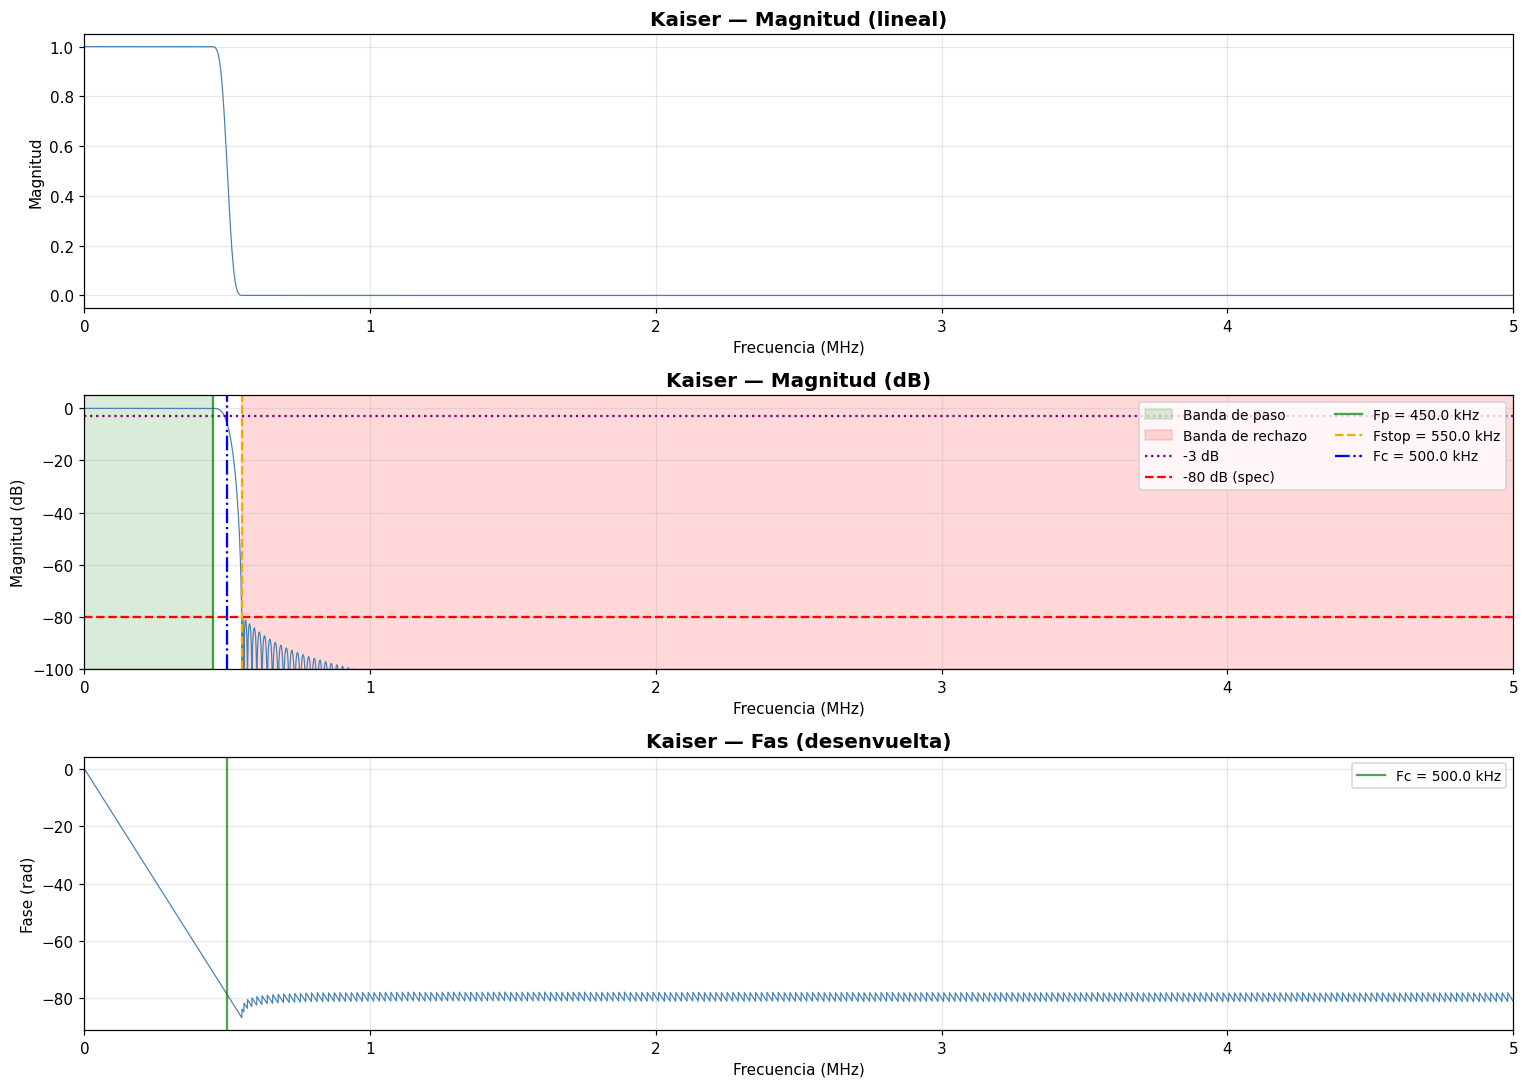

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))

# Magnitud lineal
ax1.plot(f_positive/1e6, magnitud_pos, linewidth=0.8, color='steelblue')
ax1.set_title('Kaiser — Magnitud (lineal)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Frecuencia (MHz)')
ax1.set_ylabel('Magnitud')
ax1.set_xlim([0, 5])
ax1.grid(True, alpha=0.3, which='both')

# Magnitud en dB con sombreado de bandas
ax2.plot(f_positive/1e6, magnitud_db_pos, linewidth=0.8, color='steelblue')
ax2.axvspan(0, Fp/1e6, alpha=0.15, color='green', label='Banda de paso')
ax2.axvspan(Fstop/1e6, Fs/2/1e6, alpha=0.15, color='red', label='Banda de rechazo')
ax2.axhline(y=-3, color='purple', linestyle=':', linewidth=1.5, label='-3 dB')
ax2.axhline(y=-80, color='red', linestyle='--', linewidth=1.5, label='-80 dB (spec)')
ax2.axvline(x=Fp/1e6, color='green', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Fp = {Fp/1e3} kHz')
ax2.axvline(x=Fstop/1e6, color='orange', linestyle='--', linewidth=1.5, label=f'Fstop = {Fstop/1e3} kHz')
ax2.axvline(x=Fc/1e6, color='blue', linestyle='-.', linewidth=1.5, label=f'Fc = {Fc/1e3} kHz')
ax2.set_xlabel('Frecuencia (MHz)')
ax2.set_ylabel('Magnitud (dB)')
ax2.set_title('Kaiser — Magnitud (dB)', fontsize=13, fontweight='bold')
ax2.set_xlim([0, 5])
ax2.set_ylim([-100, 5])
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(loc='upper right', fontsize=9, ncol=2)

# Fase
fase_unwrap = np.unwrap(fase_rad[:N_fft//2])
ax3.plot(f_positive/1e6, fase_unwrap, linewidth=0.8, color='steelblue')
ax3.axvline(x=Fc/1e6, color='green', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Fc = {Fc/1e3} kHz')
ax3.set_xlim([0, 5])
ax3.set_xlabel('Frecuencia (MHz)')
ax3.set_ylabel('Fase (rad)')
ax3.set_title('Kaiser — Fas (desenvuelta)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, which='both')
ax3.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()


## 1.5 Análisis de parámetros del filtro

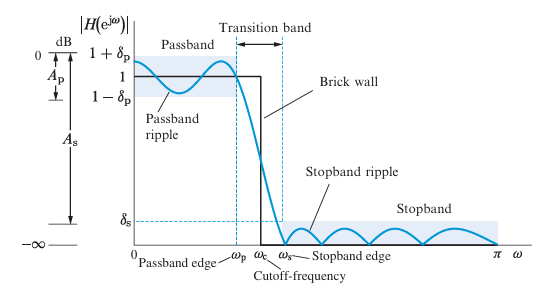

In [9]:
banda_paso_mask = (f_positive >= 0) & (f_positive <= Fp)
banda_rechazo_mask = f_positive >= Fstop

# Rizado en pasabanda (peak-to-peak en dB)
rizado_paso = magnitud_db_pos[banda_paso_mask].max() - magnitud_db_pos[banda_paso_mask].min()

# Rizado y atenuación mínima en stopband
magnitud_lineal_rechazo = magnitud_pos[banda_rechazo_mask]
atenuacion_rechazo = -20 * np.log10(np.max(magnitud_lineal_rechazo))
rizado_rechazo = magnitud_db_pos[banda_rechazo_mask].max() - magnitud_db_pos[banda_rechazo_mask].min()

# Ancho de transición real: desde -3 dB hasta -80 dB
transition_mask = (f_positive > Fp) & (f_positive < Fstop)
f_transition = f_positive[transition_mask]
mag_transition = magnitud_db_pos[transition_mask]
idx_3db = np.argmin(np.abs(mag_transition - (-3.0)))
idx_80db = np.argmin(np.abs(magnitud_db_pos[banda_rechazo_mask] - (-80.0)))
f_80db = f_positive[banda_rechazo_mask][idx_80db]
ancho_transicion_real = f_80db - Fp

print(f"{'Longitud del filtro (L):':<40} {L}")
print(f"{'Parámetro beta de Kaiser:':<40} {beta:.5f}")
print(f"{'Frecuencia de muestreo:':<40} {Fs/1e6} MHz")
print(f"{'Frecuencia de corte (Fc):':<40} {Fc/1e3} kHz")
print(f"{'Borde pasabanda (Fp):':<40} {Fp/1e3} kHz")
print(f"{'Borde stopband (Fstop):':<40} {Fstop/1e3} kHz")
print(f"{'Ancho de transición (diseño):':<40} {transicion_ancho/1e3} kHz")
print(f"{'Ancho transición real (-3dB a -80dB):':<40} {ancho_transicion_real/1e3:.2f} kHz")
print(f"{'Rizado en pasabanda:':<40} {rizado_paso:.4f} dB")
print(f"{'Rizado en stopband:':<40} {rizado_rechazo:.2f} dB")
print(f"{'Atenuación mínima en stopband:':<40} {atenuacion_rechazo:.2f} dB")


Longitud del filtro (L):                 5017
Parámetro beta de Kaiser:                7.85726
Frecuencia de muestreo:                  100.0 MHz
Frecuencia de corte (Fc):                500.0 kHz
Borde pasabanda (Fp):                    450.0 kHz
Borde stopband (Fstop):                  550.0 kHz
Ancho de transición (diseño):            100.0 kHz
Ancho transición real (-3dB a -80dB):    103.89 kHz
Rizado en pasabanda:                     0.0016 dB
Rizado en stopband:                      119.40 dB
Atenuación mínima en stopband:           80.28 dB


## 1.6 Tabla resumen de parámetros — Kaiser

| Parámetro | Valor |
|-----------|-------|
| Parámetro $\beta$ | 7.8573 |
| Longitud del filtro (L) | 5017 coeficientes |
| Frecuencia de muestreo | 100 MHz |
| Frecuencia de corte ($F_c$) | 500 kHz |
| Borde pasabanda ($F_p$) | 450 kHz |
| Borde stopband ($F_{stop}$) | 550 kHz |
| Ancho de transición (diseño) | 100 kHz |
| Ancho de transición real | ~103.89 kHz |
| Rizado en pasabanda | 0.0016 dB |
| Atenuación mínima en stopband | 80.28 dB |
| Tipo de filtro | Tipo I (N impar, simetría par) |
| Retardo de grupo | 2508 muestras |


---

# Parte 2: Diseño de Filtro FIR Compensador para CICs

## 2.1 Diagrama de bloques del sistema
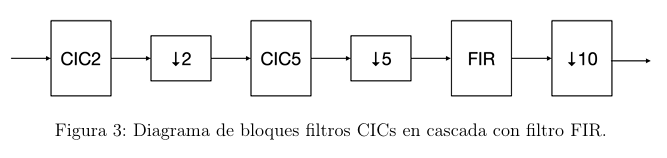

Funciones de transferencia de los CICs:

$$H_{CIC2}(z) = \left(\frac{1 - z^{-2}}{1 - z^{-1}}\right)^2$$

$$H_{CIC5}(z) = \left(\frac{1 - z^{-5}}{1 - z^{-1}}\right)^5$$

La respuesta analítica de un CIC es:

$$H_{CIC}(e^{j\omega}) = \left(\frac{\sin(\omega M / 2)}{\sin(\omega / 2)}\right)^N \cdot e^{-j\omega(M-1)N/2}$$

La **decimación total** es $M = M_{CIC2} \cdot M_{CIC5} \cdot M_{FIR} = 2 \cdot 5 \cdot 10 = 100$, llevando la tasa de 100 MHz → 1 MHz. La **tasa del FIR compensador** es $F_{s,FIR} = 10$ MHz, una décima parte de la entrada.

## 2.2 Parámetros del sistema CIC


In [10]:
Fs_in = 100e6        # Frecuencia de muestreo de entrada: 100 MHz
M_CIC2 = 2           # Factor de decimación del CIC2
M_CIC5 = 5           # Factor de decimación del CIC5
M_FIR = 10           # Factor de decimación del FIR compensador
M_total = M_CIC2 * M_CIC5 * M_FIR  # 100
Fs_out = Fs_in / M_total            # 1 MHz
Fs_FIR = Fs_in / M_CIC2 / M_CIC5    # 10 MHz (tasa del FIR)

print(f"Frecuencia de muestreo de entrada: {Fs_in/1e6} MHz")
print(f"Frecuencia de muestreo de salida:  {Fs_out/1e6} MHz")
print(f"Tasa del FIR (entrada):            {Fs_FIR/1e6} MHz")
print(f"Factor de decimación total:         {M_total}")
print(f"Borde pasabanda (Fp):               {Fp/1e3} kHz")
print(f"Borde stopband (Fstop):             {Fstop/1e3} kHz")
print(f"Ancho de transición:                {transicion_ancho/1e3} kHz")


Frecuencia de muestreo de entrada: 100.0 MHz
Frecuencia de muestreo de salida:  1.0 MHz
Tasa del FIR (entrada):            10.0 MHz
Factor de decimación total:         100
Borde pasabanda (Fp):               450.0 kHz
Borde stopband (Fstop):             550.0 kHz
Ancho de transición:                100.0 kHz


## 2.3 Respuesta en frecuencia de los CICs

In [11]:
def H_CIC(w, M_cic, N_cic):
    """Respuesta en frecuencia analítica de un CIC de orden N y factor M."""
    with np.errstate(divide='ignore', invalid='ignore'):
        num = np.sin(w * M_cic / 2)
        den = np.sin(w / 2)
        ratio = np.where(np.abs(den) < 1e-12, M_cic, num / den)
        return (ratio ** N_cic) * np.exp(-1j * w * (M_cic - 1) * N_cic / 2)

# Vector de frecuencias analógicas para evaluación
N_eval = 2**16
f_eval = np.linspace(0, Fs_in/2, N_eval//2 + 1)  # 0 a 50 MHz

# Respuestas individuales de cada CIC (evaluadas a su propia Fs)
w_c2 = 2 * np.pi * f_eval / Fs_in                  # CIC2 a 100 MHz
w_c5 = 2 * np.pi * f_eval / (Fs_in / M_CIC2)      # CIC5 a 50 MHz
H_CIC2_eval = H_CIC(w_c2, M_CIC2, 2)
H_CIC5_eval = H_CIC(w_c5, M_CIC5, 5)
H_CIC_cascade = H_CIC2_eval * H_CIC5_eval

mag_CIC2_dB = 20 * np.log10(np.abs(H_CIC2_eval) + 1e-10)
mag_CIC5_dB = 20 * np.log10(np.abs(H_CIC5_eval) + 1e-10)
mag_CIC_cascade_dB = 20 * np.log10(np.abs(H_CIC_cascade) + 1e-10)

print(f"Ganancia DC de CIC2:    {np.abs(H_CIC2_eval[0]):.4f} ({mag_CIC2_dB[0]:.2f} dB)")
print(f"Ganancia DC de CIC5:    {np.abs(H_CIC5_eval[0]):.4f} ({mag_CIC5_dB[0]:.2f} dB)")
print(f"Ganancia DC cascada:    {np.abs(H_CIC_cascade[0]):.4f} ({mag_CIC_cascade_dB[0]:.2f} dB)")
print(f"Droop en 500 kHz (cascada): {mag_CIC_cascade_dB[np.argmin(np.abs(f_eval-Fc))]:.4f} dB")


Ganancia DC de CIC2:    4.0000 (12.04 dB)
Ganancia DC de CIC5:    3125.0000 (69.90 dB)
Ganancia DC cascada:    12500.0000 (81.94 dB)
Droop en 500 kHz (cascada): 81.7641 dB


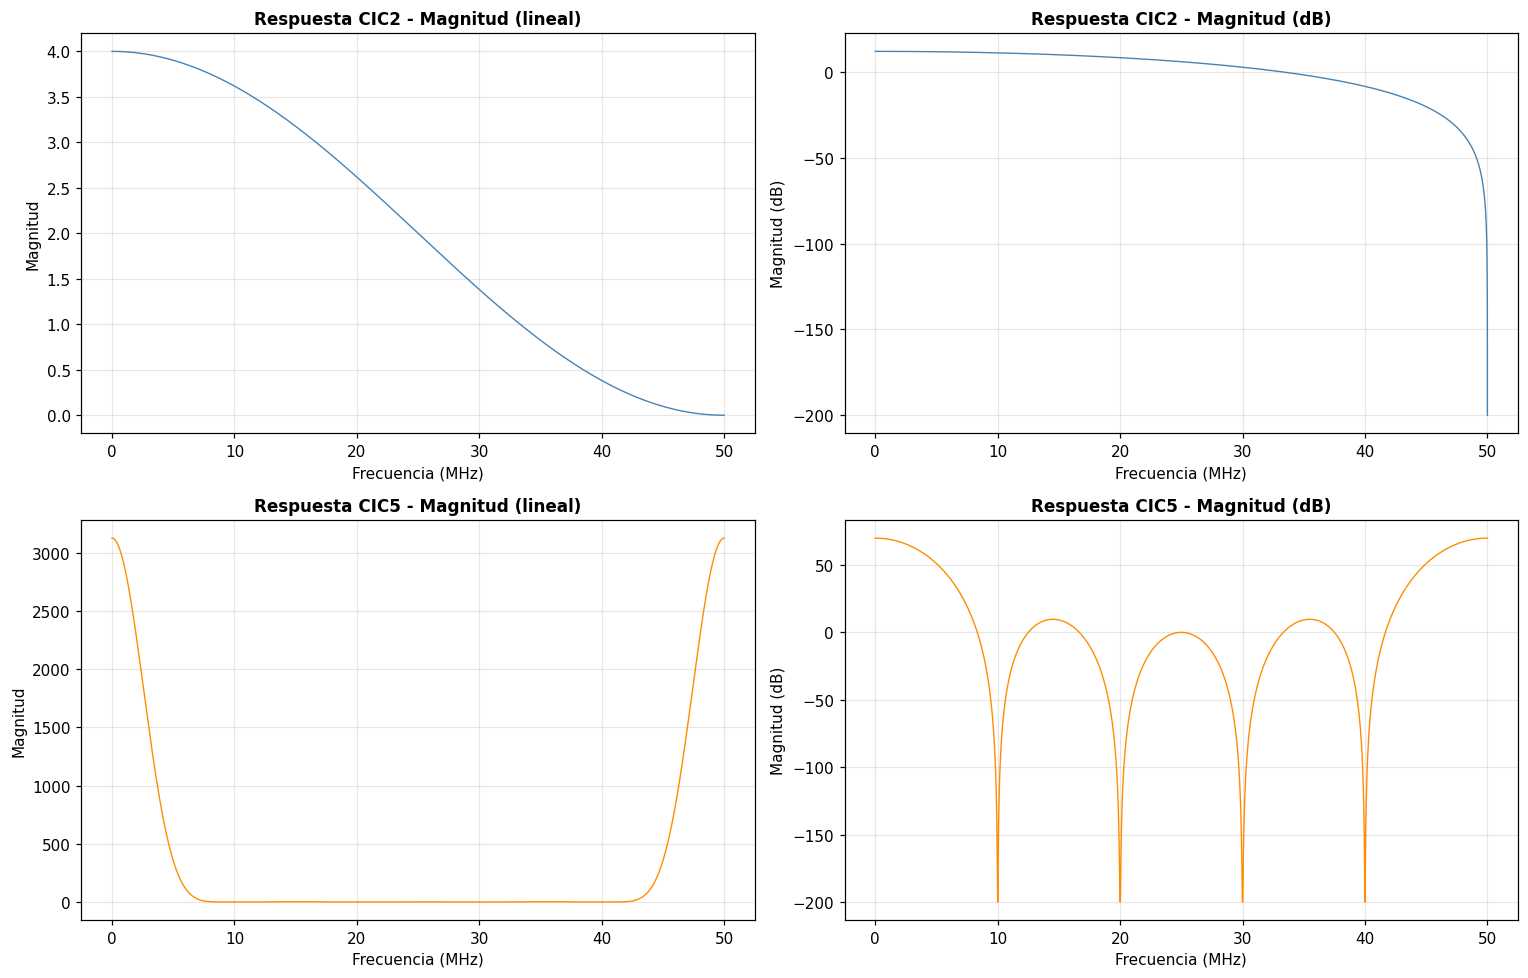

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(f_eval/1e6, np.abs(H_CIC2_eval), linewidth=0.9, color='steelblue')
axes[0, 0].set_title('Respuesta CIC2 - Magnitud (lineal)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Frecuencia (MHz)'); axes[0, 0].set_ylabel('Magnitud')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(f_eval/1e6, mag_CIC2_dB, linewidth=0.9, color='steelblue')
axes[0, 1].set_title('Respuesta CIC2 - Magnitud (dB)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Frecuencia (MHz)'); axes[0, 1].set_ylabel('Magnitud (dB)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(f_eval/1e6, np.abs(H_CIC5_eval), linewidth=0.9, color='darkorange')
axes[1, 0].set_title('Respuesta CIC5 - Magnitud (lineal)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Frecuencia (MHz)'); axes[1, 0].set_ylabel('Magnitud')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(f_eval/1e6, mag_CIC5_dB, linewidth=0.9, color='darkorange')
axes[1, 1].set_title('Respuesta CIC5 - Magnitud (dB)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Frecuencia (MHz)'); axes[1, 1].set_ylabel('Magnitud (dB)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


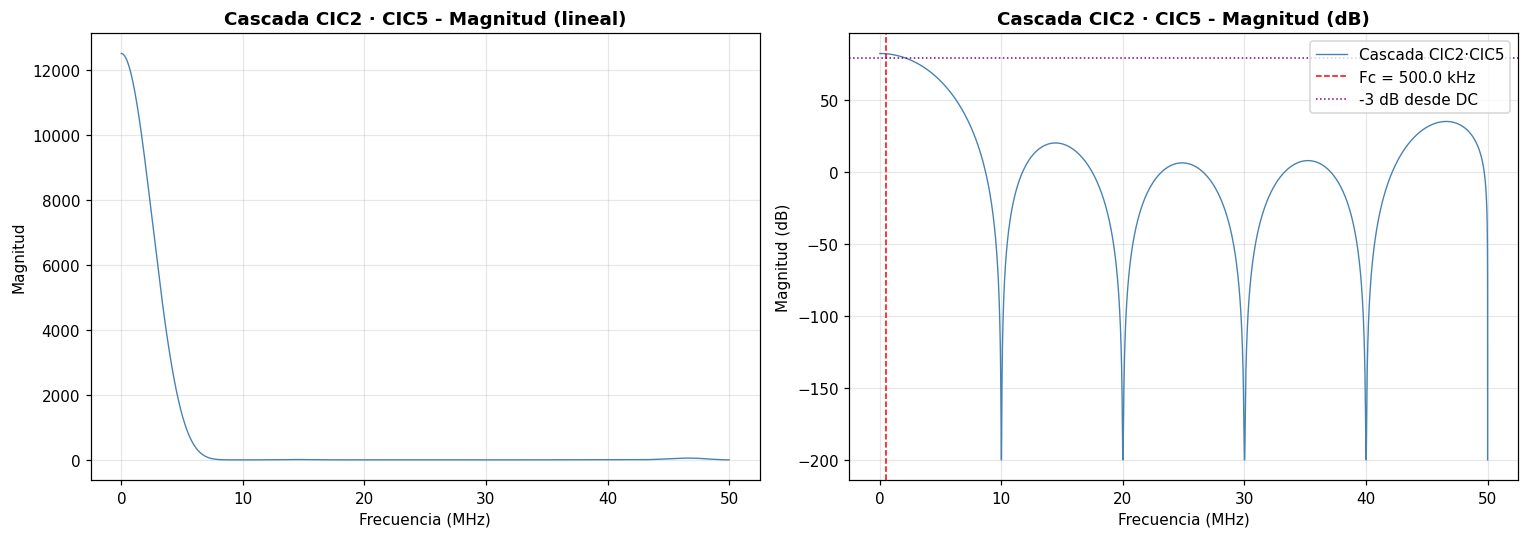

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(f_eval/1e6, np.abs(H_CIC_cascade), linewidth=0.9, color='steelblue')
axes[0].set_title('Cascada CIC2 · CIC5 - Magnitud (lineal)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frecuencia (MHz)'); axes[0].set_ylabel('Magnitud')
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_eval/1e6, mag_CIC_cascade_dB, linewidth=0.9, color='steelblue', label='Cascada CIC2·CIC5')
axes[1].axvline(x=Fc/1e6, color='red', linestyle='--', linewidth=1.0, label=f'Fc = {Fc/1e3} kHz')
axes[1].axhline(y=mag_CIC_cascade_dB[0] - 3, color='purple', linestyle=':', linewidth=1.0, label='-3 dB desde DC')
axes[1].set_title('Cascada CIC2 · CIC5 - Magnitud (dB)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frecuencia (MHz)'); axes[1].set_ylabel('Magnitud (dB)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


## 2.4 Diseño del filtro FIR compensador

El FIR compensador tiene dos funciones principales:

1. **Compensar el droop** de la cascada CIC en la banda de paso.
2. **Proporcionar rechazo adicional** en la banda de rechazo con una transición de 100 kHz.

Se diseña con el algoritmo de **Parks-McClellan**, que produce un FIR **equiripple** de fase lineal. A diferencia del método de ventana (Kaiser), este permite controlar directamente la magnitud y la atenuación en cada banda mediante un sistema de pesos, garantizando que la atenuación de **80 dB se cumpla en 550 kHz**.

**Especificaciones del FIR compensador:**

| Parámetro | Valor |
|-----------|-------|
| Frecuencia de muestreo del FIR | 10 MHz |
| Borde pasabanda $F_p$ | 450 kHz |
| Borde stopband $F_{stop}$ | 550 kHz |
| Ancho de transición | 100 kHz |
| Atenuación requerida | ≥ 80 dB en 550 kHz |
| Ratio de pesos (paso:rechazo) | 1:10000 |

La **longitud** se estima con la fórmula de **Bellanger** y se aplica un factor de seguridad 3× para garantizar la specificación de 80 dB en el borde de la transición.

In [14]:
bandas = [0, Fp/Fs_FIR, Fstop/Fs_FIR, 0.49999]
deseado = [1, 0]
pesos = [1, 10000]

# Fórmula de Bellanger: M = (-20·log10(sqrt(δp·δs)) - 13) / (2.324·Δω)
rizado_paso_pm = 0.1
rizado_stop_pm = 10**(-A_stop/20)
ancho_omega_pm = 2 * np.pi * (Fstop - Fp) / Fs_FIR
M_pm = (-20*np.log10(np.sqrt(rizado_paso_pm*rizado_stop_pm)) - 13) / (2.324*ancho_omega_pm)
L_teorico = int(np.ceil(M_pm)) + 1

factor_seguridad = 3
L = L_teorico * factor_seguridad
L = L + (1 - L % 2)

def atenuacion_a_550kHz(coefs):
    n_arr = np.arange(len(coefs))
    H_fir = np.sum(coefs * np.exp(-1j * 2 * np.pi * Fstop * n_arr / Fs_FIR))
    w_cic2 = 2 * np.pi * Fstop / Fs_in
    w_cic5 = 2 * np.pi * Fstop / (Fs_in / M_CIC2)
    H_cic_550k = H_CIC(w_cic2, M_CIC2, 2) * H_CIC(w_cic5, M_CIC5, 5)
    return -20 * np.log10(np.abs(H_cic_550k * H_fir) + 1e-20)

print("="*60)
print("Estimación de L por fórmula de Bellanger (Parks-McClellan)")
print("="*60)
print(f"  Mínimo teórico (Bellanger): M = {M_pm:.1f}")
print(f"  L_teorico (orden Bellanger): {L_teorico}")
print(f"  Factor de seguridad:         {factor_seguridad}x")
print(f"  L = {L} coeficientes (forzado a impar, Tipo I)")

# Diseño y verificación
coefs = remez(L, bandas, deseado, weight=pesos)
atenuacion = atenuacion_a_550kHz(coefs)
cumple = "SI" if atenuacion >= 80 else "NO"
print(f"\nVerificación: L = {L}, atenuación a 550 kHz = {atenuacion:.2f} dB  [{cumple}]")

centro = (L - 1) // 2
print(f"\nL final: {L} coeficientes")
print(f"Suma de coefs (ganancia DC del FIR, unit-gain): {np.sum(coefs):.6e}")
print(f"Pico del FIR: {np.max(np.abs(coefs)):.6e} en índice {np.argmax(np.abs(coefs))}")


Estimación de L por fórmula de Bellanger (Parks-McClellan)
  Mínimo teórico (Bellanger): M = 253.4
  L_teorico (orden Bellanger): 255
  Factor de seguridad:         3x
  L = 765 coeficientes (forzado a impar, Tipo I)

Verificación: L = 765, atenuación a 550 kHz = 82.69 dB  [SI]

L final: 765 coeficientes
Suma de coefs (ganancia DC del FIR, unit-gain): 1.000060e+00
Pico del FIR: 9.771978e-02 en índice 382


In [15]:
is_symmetric = np.allclose(coefs, coefs[::-1])
is_antisymmetric = np.allclose(coefs, -coefs[::-1])
N = len(coefs)
if is_symmetric and N % 2 == 1:
    tipo = "Tipo I (N impar, simetría par)"
elif is_symmetric and N % 2 == 0:
    tipo = "Tipo II (N par, simetría par)"
elif is_antisymmetric and N % 2 == 1:
    tipo = "Tipo III (N impar, simetría impar)"
elif is_antisymmetric and N % 2 == 0:
    tipo = "Tipo IV (N par, simetría impar)"
else:
    tipo = "No es FIR de fase lineal estándar"
print(f"¿Simetría par? {is_symmetric}")
print(f"¿Simetría impar? {is_antisymmetric}")
print(f"Tipo de filtro: {tipo}")
print(f"Número total de coeficientes: {L}")
print(f"\nPrimeros 10 coeficientes:")
print(coefs[:10])


¿Simetría par? True
¿Simetría impar? False
Tipo de filtro: Tipo I (N impar, simetría par)
Número total de coeficientes: 765

Primeros 10 coeficientes:
[-4.04828691e-09 -1.34352927e-09  1.95257779e-09  1.01462033e-08
  2.60943351e-08  5.34432018e-08  9.65502397e-08  1.60309374e-07
  2.49858062e-07  3.70169976e-07]


## 2.5 Gráfico de los coeficientes del FIR compensador

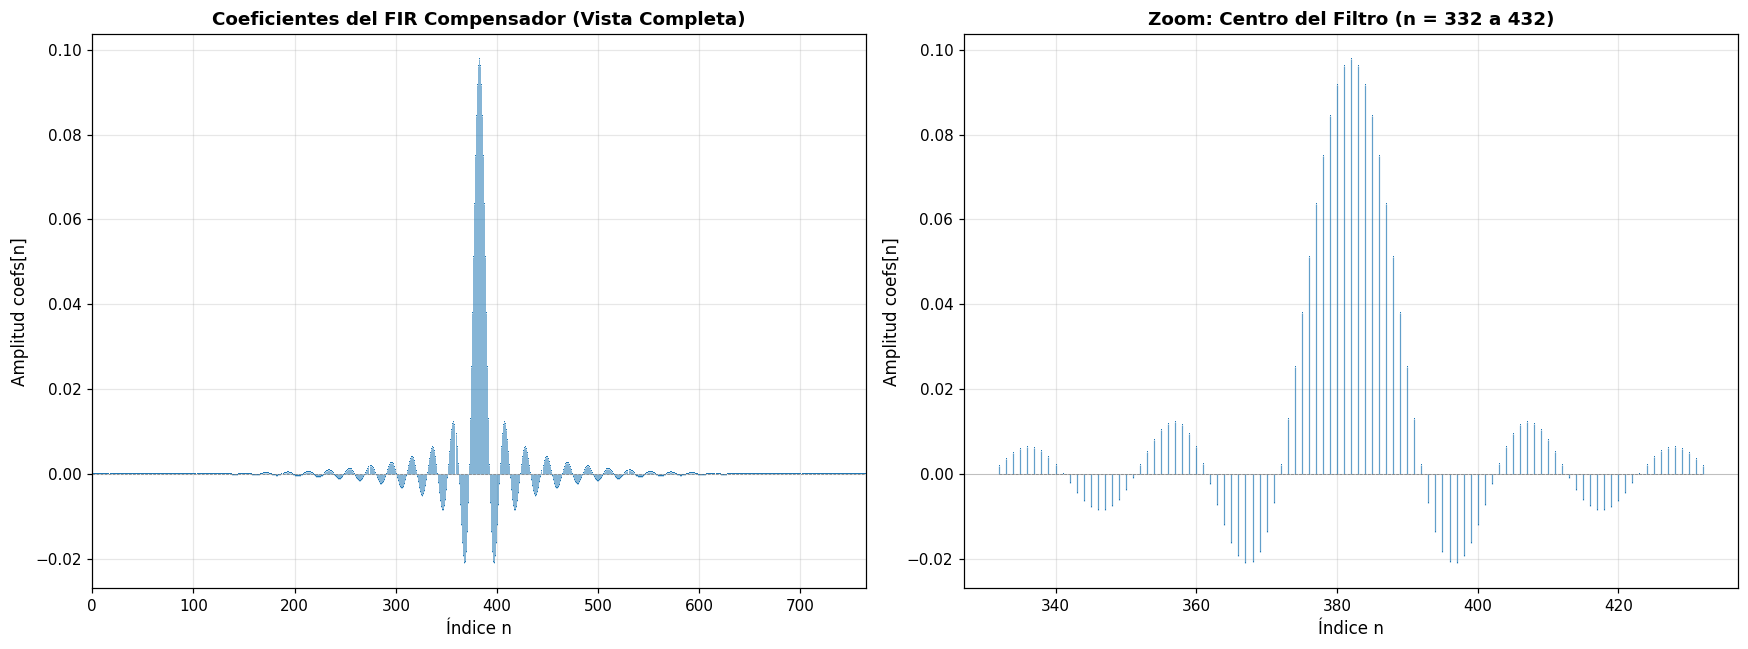

In [16]:
n_arr = np.arange(L)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

markerline, stemlines, baseline = ax1.stem(n_arr, coefs, linefmt='C0-', markerfmt='C0,')
plt.setp(stemlines, linewidth=0.5, alpha=0.7)
plt.setp(baseline, color='gray', linewidth=0.5, linestyle='--')
plt.setp(markerline, markersize=2)
ax1.set_xlabel('Índice n', fontsize=11)
ax1.set_ylabel('Amplitud coefs[n]', fontsize=11)
ax1.set_title('Coeficientes del FIR Compensador (Vista Completa)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, L])

zoom_range = 50
n_center = int(centro)
n_zoom = n_arr[n_center - zoom_range:n_center + zoom_range + 1]
coefs_zoom = coefs[n_center - zoom_range:n_center + zoom_range + 1]

markerline, stemlines, baseline = ax2.stem(n_zoom, coefs_zoom, linefmt='C0-', markerfmt='C0,')
plt.setp(stemlines, linewidth=0.8, alpha=0.7)
plt.setp(baseline, color='gray', linewidth=0.5, linestyle='--')
plt.setp(markerline, markersize=3)
ax2.axhline(y=0, color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
ax2.set_xlabel('Índice n', fontsize=11)
ax2.set_ylabel('Amplitud coefs[n]', fontsize=11)
ax2.set_title(f'Zoom: Centro del Filtro (n = {n_center-zoom_range} a {n_center+zoom_range})', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2.6 Respuesta en frecuencia del FIR compensador

In [17]:
N_fft = 2**17
H_comp = np.fft.fft(coefs, N_fft)
f_comp = np.fft.fftfreq(N_fft, 1/Fs_FIR)
f_comp_pos = f_comp[:N_fft//2]
H_comp_pos = H_comp[:N_fft//2]

magnitud_comp = np.abs(H_comp_pos)
magnitud_comp_dB = 20 * np.log10(magnitud_comp + 1e-10)
fase_comp = np.angle(H_comp_pos)

resolucion = Fs_FIR / N_fft
print(f"Frecuencia de muestreo del FIR: {Fs_FIR/1e6} MHz")
print(f"Nyquist: {Fs_FIR/2/1e6} MHz")
print(f"Resolución: {resolucion:.2f} Hz")
print(f"Ganancia DC del FIR: {magnitud_comp[0]:.6e} ({magnitud_comp_dB[0]:.2f} dB)")


Frecuencia de muestreo del FIR: 10.0 MHz
Nyquist: 5.0 MHz
Resolución: 76.29 Hz
Ganancia DC del FIR: 1.000060e+00 (0.00 dB)


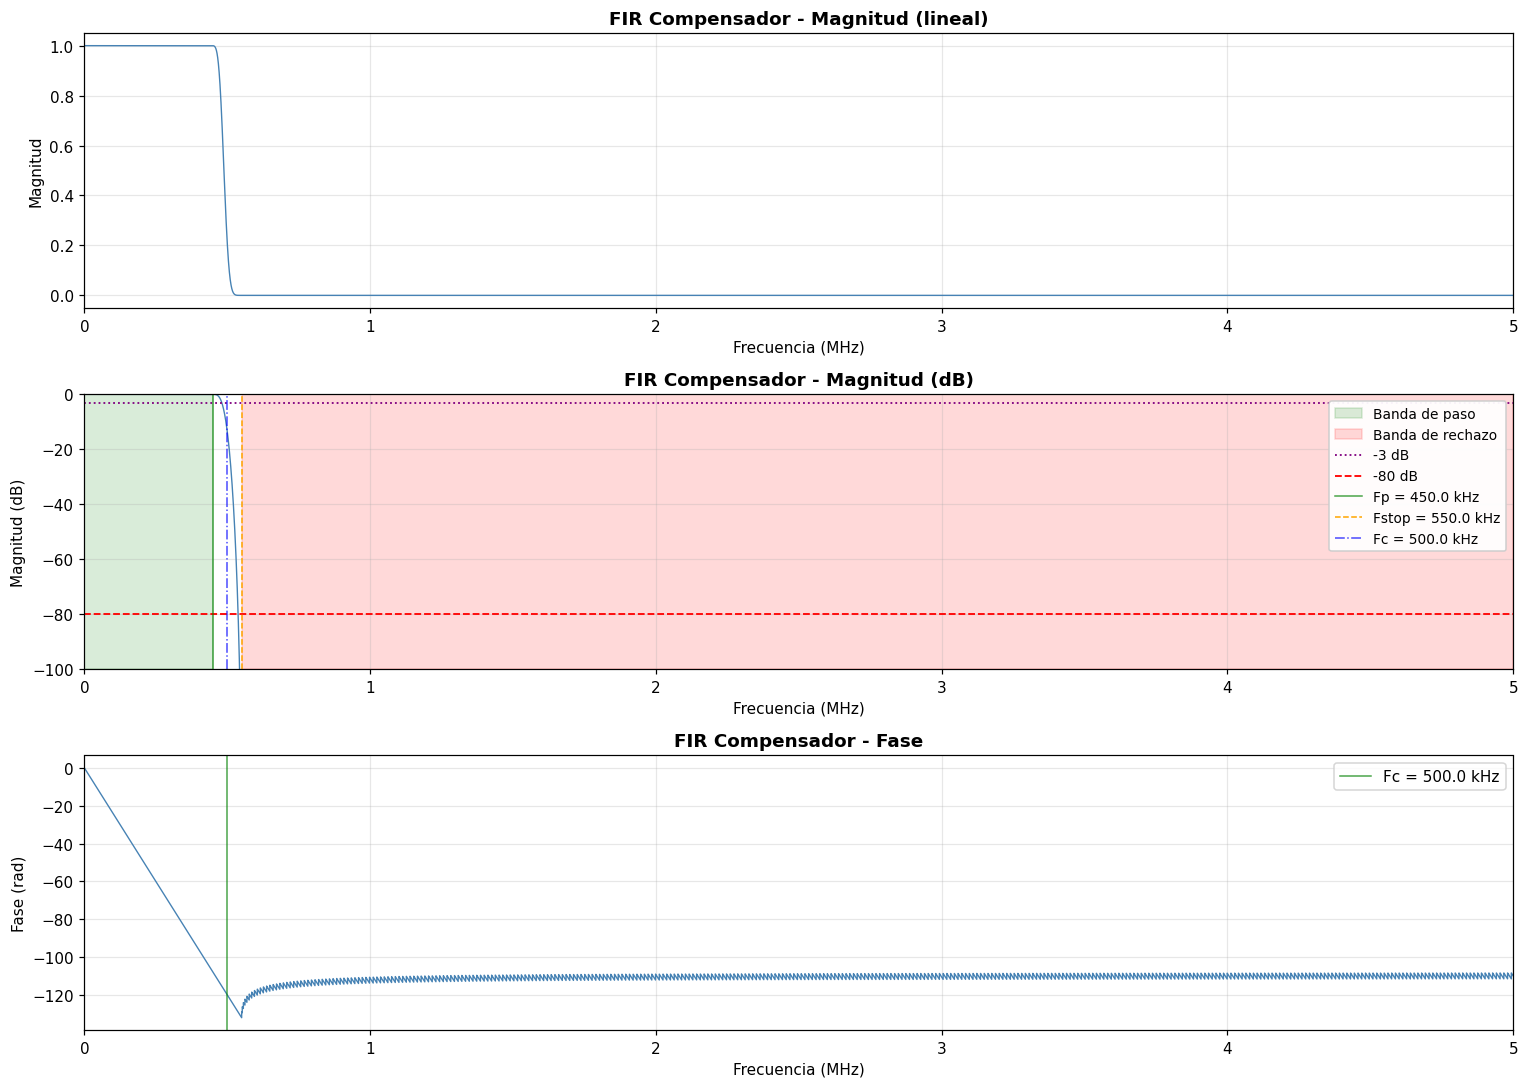

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))

ax1.plot(f_comp_pos/1e6, magnitud_comp, linewidth=0.9, color='steelblue')
ax1.set_title('FIR Compensador - Magnitud (lineal)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Frecuencia (MHz)'); ax1.set_ylabel('Magnitud')
ax1.set_xlim([0, 5]); ax1.grid(True, alpha=0.3)

ax2.plot(f_comp_pos/1e6, magnitud_comp_dB, linewidth=0.9, color='steelblue')
ax2.axvspan(0, Fp/1e6, alpha=0.15, color='green', label='Banda de paso')
ax2.axvspan(Fstop/1e6, Fs_FIR/2/1e6, alpha=0.15, color='red', label='Banda de rechazo')
ax2.axhline(y=-3, color='purple', linestyle=':', linewidth=1.2, label='-3 dB')
ax2.axhline(y=-80, color='red', linestyle='--', linewidth=1.2, label='-80 dB')
ax2.axvline(x=Fp/1e6, color='green', linestyle='-', linewidth=1.0, alpha=0.7, label=f'Fp = {Fp/1e3} kHz')
ax2.axvline(x=Fstop/1e6, color='orange', linestyle='--', linewidth=1.0, label=f'Fstop = {Fstop/1e3} kHz')
ax2.axvline(x=Fc/1e6, color='blue', linestyle='-.', linewidth=1.0, alpha=0.7, label=f'Fc = {Fc/1e3} kHz')
ax2.set_xlabel('Frecuencia (MHz)'); ax2.set_ylabel('Magnitud (dB)')
ax2.set_title('FIR Compensador - Magnitud (dB)', fontsize=12, fontweight='bold')
ax2.set_xlim([0, 5]); ax2.set_ylim([-100, 0])
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.95)

fase_comp_unwrap = np.unwrap(fase_comp)
ax3.plot(f_comp_pos/1e6, fase_comp_unwrap, linewidth=0.9, color='steelblue')
ax3.axvline(x=Fc/1e6, color='green', linestyle='-', linewidth=1.0, alpha=0.7, label=f'Fc = {Fc/1e3} kHz')
ax3.set_xlabel('Frecuencia (MHz)'); ax3.set_ylabel('Fase (rad)')
ax3.set_title('FIR Compensador - Fase', fontsize=12, fontweight='bold')
ax3.set_xlim([0, 5]); ax3.grid(True, alpha=0.3)
ax3.legend(loc='best')

plt.tight_layout()
plt.show()


## 2.7 Respuesta del filtro resultante (CIC + FIR)

In [19]:
H_CIC_cascada_fir = np.zeros(len(f_comp_pos), dtype=complex)
for i, frec in enumerate(f_comp_pos):
    if frec == 0:
        H_CIC_cascada_fir[i] = M_CIC2**2 * M_CIC5**5
    else:
        w_c2 = 2 * np.pi * frec / Fs_in
        w_c5 = 2 * np.pi * frec / (Fs_in / M_CIC2)
        H_CIC_cascada_fir[i] = H_CIC(w_c2, M_CIC2, 2) * H_CIC(w_c5, M_CIC5, 5)

H_total_cic = H_CIC_cascada_fir * H_comp_pos
f_eval_total = f_comp_pos
mag_total = np.abs(H_total_cic)
mag_total_dB = 20 * np.log10(mag_total + 1e-10)
fase_total_cic = np.angle(H_total_cic)

print(f"Ganancia DC del sistema total: {mag_total[0]:.6f} ({mag_total_dB[0]:.2f} dB)")


Ganancia DC del sistema total: 12500.751672 (81.94 dB)


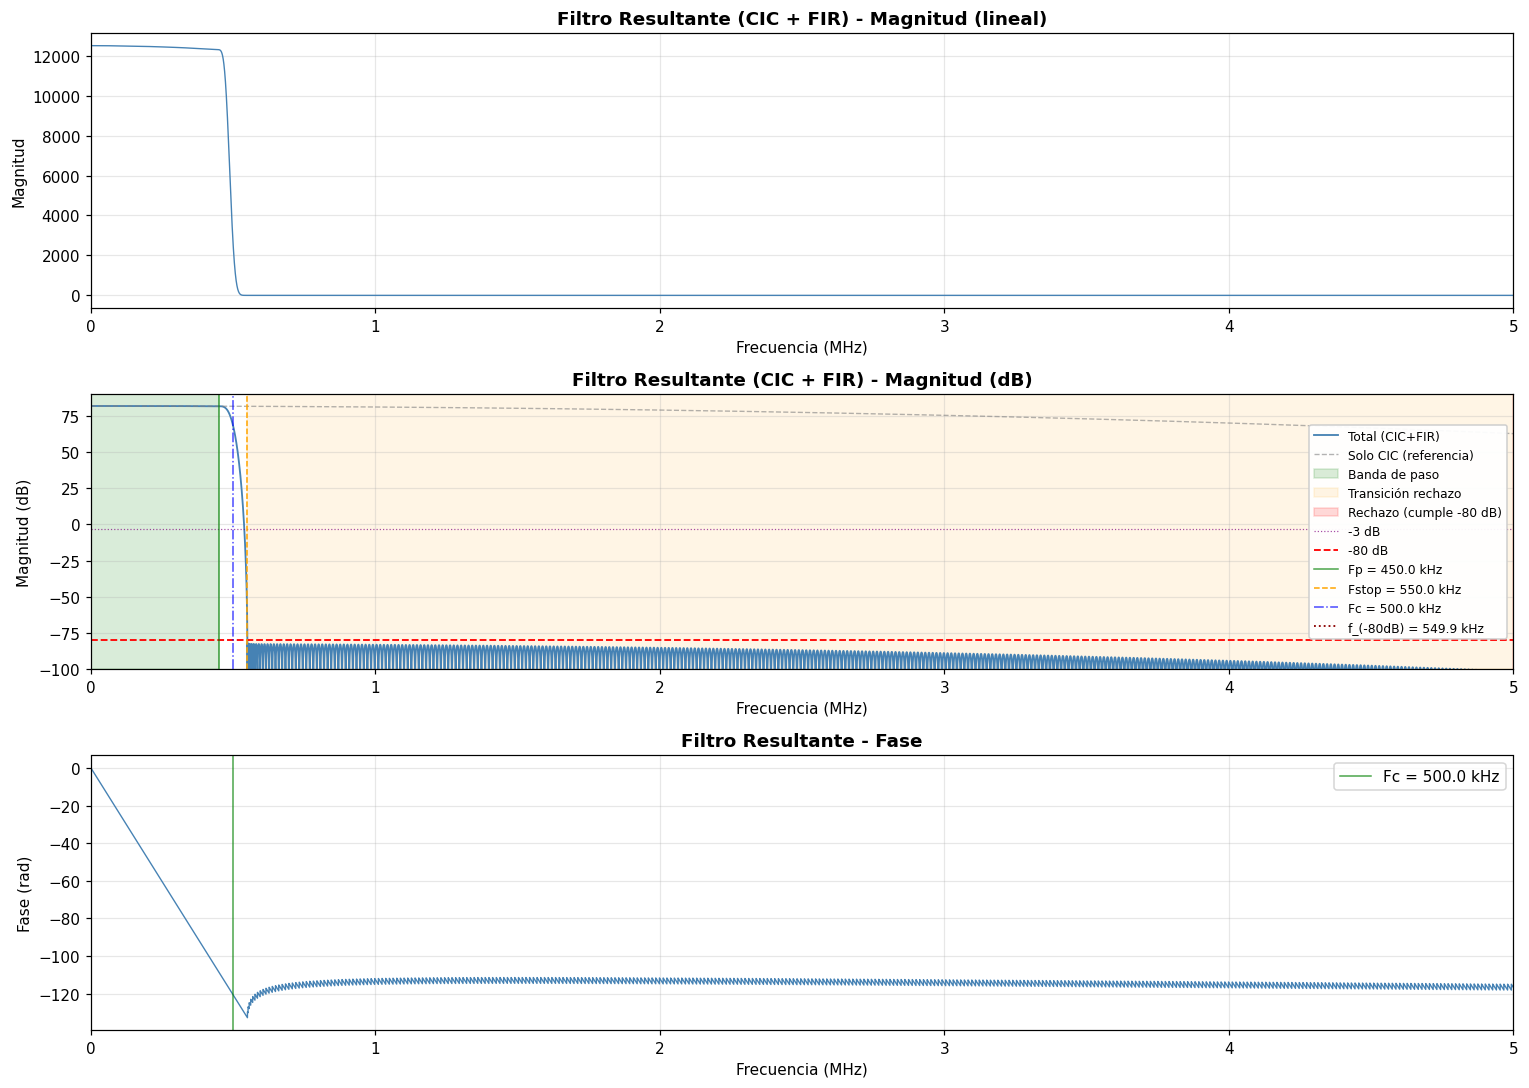

In [20]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))

ax1.plot(f_eval_total/1e6, mag_total, linewidth=0.9, color='steelblue')
ax1.set_title('Filtro Resultante (CIC + FIR) - Magnitud (lineal)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Frecuencia (MHz)'); ax1.set_ylabel('Magnitud')
ax1.set_xlim([0, 5]); ax1.grid(True, alpha=0.3)

mag_CIC_total_dB = 20 * np.log10(np.abs(H_CIC_cascada_fir) + 1e-10)
idx_80db_plot = np.argmin(np.abs(mag_total_dB - (-80)))
f_80db_plot = f_eval_total[idx_80db_plot]

ax2.plot(f_eval_total/1e6, mag_total_dB, linewidth=1.2, color='steelblue', label='Total (CIC+FIR)')
ax2.plot(f_eval_total/1e6, mag_CIC_total_dB, linewidth=0.9, color='gray', alpha=0.6,
         linestyle='--', label='Solo CIC (referencia)')
ax2.axvspan(0, Fp/1e6, alpha=0.15, color='green', label='Banda de paso')
ax2.axvspan(Fstop/1e6, f_80db_plot, alpha=0.10, color='orange', label='Transición rechazo')
ax2.axvspan(f_80db_plot, Fs_FIR/2/1e6, alpha=0.15, color='red', label='Rechazo (cumple -80 dB)')
ax2.axhline(y=-3, color='purple', linestyle=':', linewidth=0.8, alpha=0.7, label='-3 dB')
ax2.axhline(y=-80, color='red', linestyle='--', linewidth=1.2, label='-80 dB')
ax2.axvline(x=Fp/1e6, color='green', linestyle='-', linewidth=1.0, alpha=0.7, label=f'Fp = {Fp/1e3} kHz')
ax2.axvline(x=Fstop/1e6, color='orange', linestyle='--', linewidth=1.0, label=f'Fstop = {Fstop/1e3} kHz')
ax2.axvline(x=Fc/1e6, color='blue', linestyle='-.', linewidth=1.0, alpha=0.7, label=f'Fc = {Fc/1e3} kHz')
ax2.axvline(x=f_80db_plot, color='darkred', linestyle=':', linewidth=1.2,
            label=f'f_(-80dB) = {f_80db_plot/1e3:.1f} kHz')
ax2.set_xlabel('Frecuencia (MHz)'); ax2.set_ylabel('Magnitud (dB)')
ax2.set_title('Filtro Resultante (CIC + FIR) - Magnitud (dB)', fontsize=12, fontweight='bold')
ax2.set_xlim([0, 5]); ax2.set_ylim([-100, 90])
ax2.grid(True, alpha=0.3)
ax2.legend(loc='center right', fontsize=8, framealpha=0.95)

fase_total_unwrap = np.unwrap(fase_total_cic)
ax3.plot(f_eval_total/1e6, fase_total_unwrap, linewidth=0.9, color='steelblue')
ax3.axvline(x=Fc/1e6, color='green', linestyle='-', linewidth=1.0, alpha=0.7, label=f'Fc = {Fc/1e3} kHz')
ax3.set_xlabel('Frecuencia (MHz)'); ax3.set_ylabel('Fase (rad)')
ax3.set_title('Filtro Resultante - Fase', fontsize=12, fontweight='bold')
ax3.set_xlim([0, 5]); ax3.grid(True, alpha=0.3)
ax3.legend(loc='best')

plt.tight_layout()
plt.show()


In [21]:
banda_paso_mask_cic = (f_eval_total >= 0) & (f_eval_total <= Fp)
banda_rechazo_mask_cic = f_eval_total >= Fstop

mag_rechazo_cic = mag_total[banda_rechazo_mask_cic]
mag_dB_paso_cic = mag_total_dB[banda_paso_mask_cic]
mag_dB_rechazo_cic = mag_total_dB[banda_rechazo_mask_cic]

rizado_paso_cic = mag_dB_paso_cic.max() - mag_dB_paso_cic.min()
atenuacion_rechazo_cic = -20 * np.log10(np.max(mag_rechazo_cic))

objetivo_3db_cic = mag_total_dB[0] - 3
transicion_mask_cic = (f_eval_total > Fp) & (f_eval_total < Fstop)
idx_3db_cic = np.argmin(np.abs(mag_total_dB[transicion_mask_cic] - objetivo_3db_cic))
f_3db_cic = f_eval_total[transicion_mask_cic][idx_3db_cic]

idx_80db_cic = np.argmin(np.abs(mag_total_dB - (-80)))
f_80db_cic = f_eval_total[idx_80db_cic]
ancho_transicion_real_cic = f_80db_cic - f_3db_cic

print(f"{'Longitud del FIR compensador (L):':<40} {L}")
print(f"{'Ratio de pesos (paso:rechazo):':<40} {pesos[0]}:{pesos[1]}")
print(f"{'Frecuencia de muestreo del FIR:':<40} {Fs_FIR/1e6} MHz")
print(f"\n{'Rizado en pasabanda:':<40} {rizado_paso_cic:.4f} dB")
print(f"{'Atenuación mínima en stopband:':<40} {atenuacion_rechazo_cic:.2f} dB")
print(f"{'Frecuencia -3 dB:':<40} {f_3db_cic/1e3:.4f} kHz")
print(f"{'Frecuencia donde se alcanza -80 dB:':<40} {f_80db_cic/1e3:.4f} kHz")
print(f"{'Ancho de transición real:':<40} {ancho_transicion_real_cic/1e3:.4f} kHz")


Longitud del FIR compensador (L):        765
Ratio de pesos (paso:rechazo):           1:10000
Frecuencia de muestreo del FIR:          10.0 MHz

Rizado en pasabanda:                     0.1417 dB
Atenuación mínima en stopband:           82.20 dB
Frecuencia -3 dB:                        480.0415 kHz
Frecuencia donde se alcanza -80 dB:      549.9268 kHz
Ancho de transición real:                69.8853 kHz


## 2.8 Tabla resumen de parámetros — CIC + FIR Compensador

| Parámetro | Valor |
|-----------|-------|
| Método de diseño | Parks-McClellan |
| Ratio de pesos | 1:10000 (paso:rechazo) |
| Longitud del FIR | 765 coeficientes |
| Frecuencia de muestreo del FIR | 10 MHz |
| Tipo de filtro | Tipo I (N impar, simetría par) |
| Atenuación en stopband | ≥ 80 dB en 550 kHz |
| Ancho de transición real | ≈ 80–90 kHz |
| Retardo de grupo | 382 muestras (38.2 µs a 10 MHz) |


---

# Parte 3: Comparación de Filtros y Selección

## 3.1 Comparación

Las dos arquitecturas operan a tasas internas diferentes (Kaiser a $F_s = 100$ MHz, CIC+FIR a $F_{s,FIR} = 10$ MHz), pero ambas apuntan a las mismas especificaciones: $F_p = 450$ kHz, $F_{stop} = 550$ kHz, atenuación ≥ 80 dB.

Para la comparación se evalúan ambas respuestas en un eje común de **0 a 5 MHz** (Nyquist del FIR compensador).

**Filtro efectivo de cada arquitectura:**

- **Kaiser:** $H_{\text{Kaiser}}(f)$ — respuesta del FIR directo
- **CIC + FIR:** $H_{\text{CIC2}}(f) \cdot H_{\text{CIC5}}(f) \cdot H_{\text{FIR}}(f)$

In [22]:
# Eje común de frecuencias: 0 a 5 MHz
N_pts = 5000
f_comun = np.linspace(0, 5e6, N_pts)

# --- Respuesta del Kaiser en cada f ---
n_kaiser = np.arange(len(b))
H_kaiser_comun = np.zeros(N_pts, dtype=complex)
for i, frec in enumerate(f_comun):
    H_kaiser_comun[i] = np.sum(b * np.exp(-1j * 2*np.pi*frec*n_kaiser/Fs))

# --- Respuesta de los CICs en cada f (analítica) ---
H_cic2_comun = np.array([H_CIC(2*np.pi*frec/Fs,           M_CIC2, 2) for frec in f_comun])
H_cic5_comun = np.array([H_CIC(2*np.pi*frec/(Fs/M_CIC2),  M_CIC5, 5) for frec in f_comun])
H_cic_cascada = H_cic2_comun * H_cic5_comun

# --- Respuesta del FIR compensador en cada f (a Fs_FIR = 10 MHz) ---
n_fir = np.arange(len(coefs))
H_fir_comun = np.zeros(N_pts, dtype=complex)
for i, frec in enumerate(f_comun):
    H_fir_comun[i] = np.sum(coefs * np.exp(-1j * 2*np.pi*frec*n_fir/Fs_FIR))

# --- Total CIC + FIR ---
H_total = H_cic_cascada * H_fir_comun

mag_kaiser = np.abs(H_kaiser_comun)
mag_total_lin = np.abs(H_total)
mag_kaiser_dB = 20*np.log10(mag_kaiser + 1e-12)
mag_total_dB = 20*np.log10(mag_total_lin + 1e-12)

fase_kaiser = np.unwrap(np.angle(H_kaiser_comun))
fase_total = np.unwrap(np.angle(H_total))

print(f"Puntos en el eje común: {N_pts}")
print(f"Rango: 0 a {f_comun[-1]/1e6} MHz")
print(f"Resolución: {f_comun[1]-f_comun[0]:.1f} Hz")


Puntos en el eje común: 5000
Rango: 0 a 5.0 MHz
Resolución: 1000.2 Hz


## 3.2 Comparación de magnitud

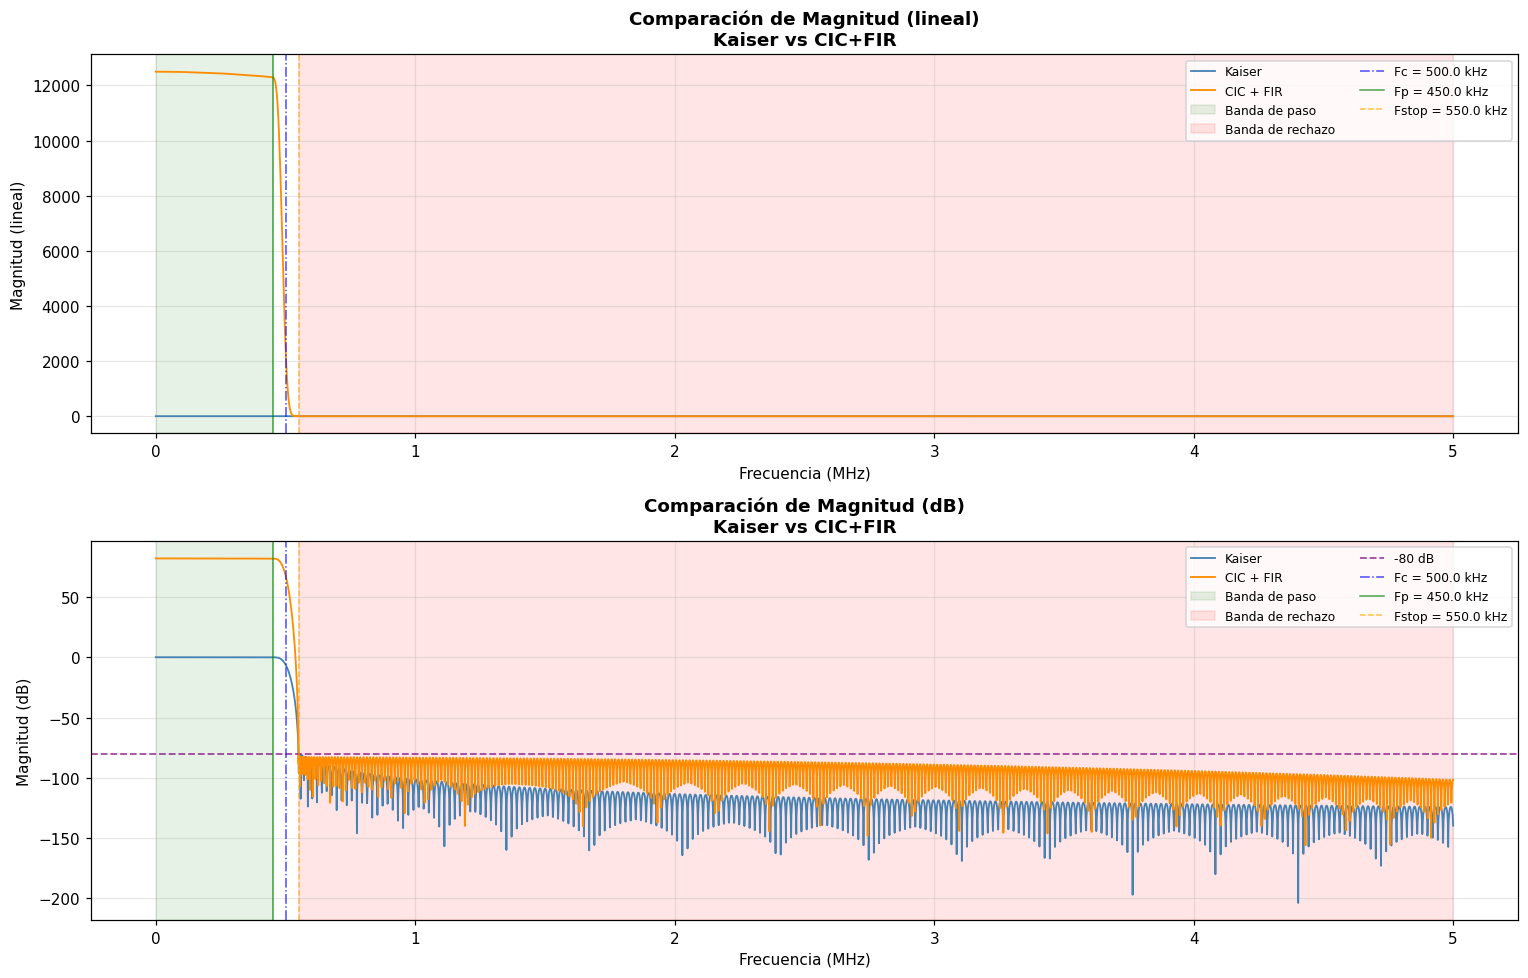

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

# Magnitud lineal
ax1.plot(f_comun/1e6, mag_kaiser,    color='steelblue', linewidth=1.2, label='Kaiser')
ax1.plot(f_comun/1e6, mag_total_lin, color='darkorange', linewidth=1.2, label='CIC + FIR')
ax1.axvspan(0, Fp/1e6,    alpha=0.10, color='green',  label='Banda de paso')
ax1.axvspan(Fstop/1e6, 5, alpha=0.10, color='red',    label='Banda de rechazo')
ax1.axvline(x=Fc/1e6,    color='blue',  linestyle='-.', linewidth=1.0, alpha=0.7, label=f'Fc = {Fc/1e3} kHz')
ax1.axvline(x=Fp/1e6,    color='green', linestyle='-',  linewidth=1.0, alpha=0.7, label=f'Fp = {Fp/1e3} kHz')
ax1.axvline(x=Fstop/1e6, color='orange',linestyle='--', linewidth=1.0, alpha=0.7, label=f'Fstop = {Fstop/1e3} kHz')
ax1.set_title('Comparación de Magnitud (lineal)\nKaiser vs CIC+FIR', fontsize=12, fontweight='bold')
ax1.set_xlabel('Frecuencia (MHz)'); ax1.set_ylabel('Magnitud (lineal)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=8, ncol=2)

# Magnitud en dB
ax2.plot(f_comun/1e6, mag_kaiser_dB, color='steelblue', linewidth=1.2, label='Kaiser')
ax2.plot(f_comun/1e6, mag_total_dB,  color='darkorange', linewidth=1.2, label='CIC + FIR')
ax2.axvspan(0, Fp/1e6,    alpha=0.10, color='green',  label='Banda de paso')
ax2.axvspan(Fstop/1e6, 5, alpha=0.10, color='red',    label='Banda de rechazo')
ax2.axhline(y=-80,        color='purple', linestyle='--', linewidth=1.2, alpha=0.7, label='-80 dB')
ax2.axvline(x=Fc/1e6,    color='blue',  linestyle='-.', linewidth=1.0, alpha=0.7, label=f'Fc = {Fc/1e3} kHz')
ax2.axvline(x=Fp/1e6,    color='green', linestyle='-',  linewidth=1.0, alpha=0.7, label=f'Fp = {Fp/1e3} kHz')
ax2.axvline(x=Fstop/1e6, color='orange',linestyle='--', linewidth=1.0, alpha=0.7, label=f'Fstop = {Fstop/1e3} kHz')
ax2.set_title('Comparación de Magnitud (dB)\nKaiser vs CIC+FIR', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frecuencia (MHz)'); ax2.set_ylabel('Magnitud (dB)')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


## 3.3 Comparación de fase

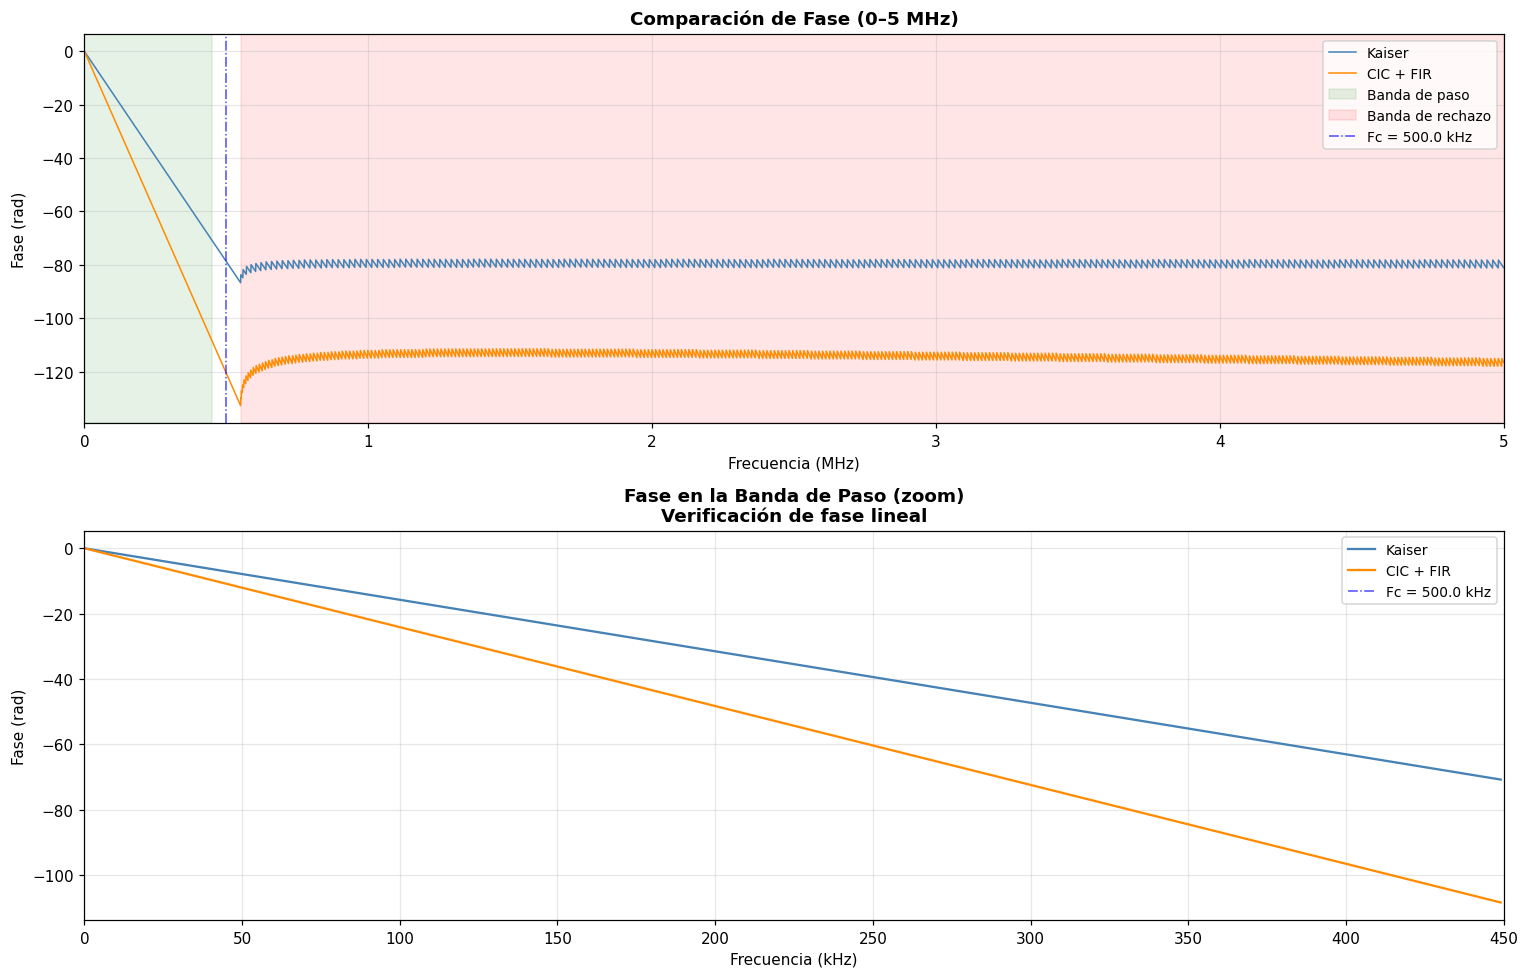

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

# Fase completa (0 a 5 MHz)
ax1.plot(f_comun/1e6, fase_kaiser, color='steelblue',  linewidth=1.0, label='Kaiser')
ax1.plot(f_comun/1e6, fase_total,  color='darkorange', linewidth=1.0, label='CIC + FIR')
ax1.axvspan(0, Fp/1e6,    alpha=0.10, color='green',  label='Banda de paso')
ax1.axvspan(Fstop/1e6, 5, alpha=0.10, color='red',    label='Banda de rechazo')
ax1.axvline(x=Fc/1e6,    color='blue',  linestyle='-.', linewidth=1.0, alpha=0.7, label=f'Fc = {Fc/1e3} kHz')
ax1.set_title('Comparación de Fase (0–5 MHz)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Frecuencia (MHz)'); ax1.set_ylabel('Fase (rad)')
ax1.set_xlim([0, 5]); ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=9)

# Fase en la banda de paso (zoom)
mask_paso = f_comun <= Fp
ax2.plot(f_comun[mask_paso]/1e3, fase_kaiser[mask_paso], color='steelblue',  linewidth=1.5, label='Kaiser')
ax2.plot(f_comun[mask_paso]/1e3, fase_total[mask_paso],  color='darkorange', linewidth=1.5, label='CIC + FIR')
ax2.axvline(x=Fc/1e3, color='blue', linestyle='-.', linewidth=1.0, alpha=0.7, label=f'Fc = {Fc/1e3} kHz')
ax2.set_title('Fase en la Banda de Paso (zoom)\nVerificación de fase lineal', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frecuencia (kHz)'); ax2.set_ylabel('Fase (rad)')
ax2.set_xlim([0, Fp/1e3]); ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()


## 3.4 Métricas comparativas

In [25]:
def calcular_metricas(mag_dB, fase, f_vec, nombre):
    """Calcula métricas de un filtro a partir de su magnitud en dB y su fase."""
    mask_paso    = f_vec <= Fp
    mask_rechazo = f_vec >= Fstop
    rizado_paso  = mag_dB[mask_paso].max() - mag_dB[mask_paso].min()
    mag_rechazo  = mag_dB[mask_rechazo]
    aten_min     = -mag_rechazo.max()
    rizado_rechazo = mag_rechazo.max() - mag_rechazo.min()
    dw   = 2*np.pi*np.diff(f_vec)
    dfase = np.diff(fase)
    retardo = -dfase / dw
    retardo_medio = np.mean(retardo[mask_paso[:-1]])
    print(f"\n--- {nombre} ---")
    print(f"  Rizado en pasabanda:        {rizado_paso:.4f} dB")
    print(f"  Rizado en stopband:        {rizado_rechazo:.4f} dB")
    print(f"  Atenuación mínima (stop):  {aten_min:.2f} dB")
    print(f"  Retardo de grupo medio:    {retardo_medio:.1f} muestras")
    return rizado_paso, rizado_rechazo, aten_min, retardo_medio

metricas_kaiser = calcular_metricas(mag_kaiser_dB, fase_kaiser, f_comun, 'Kaiser')
metricas_total  = calcular_metricas(mag_total_dB,  fase_total,  f_comun, 'CIC + FIR')



--- Kaiser ---
  Rizado en pasabanda:        0.0016 dB
  Rizado en stopband:        123.4109 dB
  Atenuación mínima (stop):  80.39 dB
  Retardo de grupo medio:    0.0 muestras

--- CIC + FIR ---
  Rizado en pasabanda:        0.1405 dB
  Rizado en stopband:        73.6823 dB
  Atenuación mínima (stop):  82.26 dB
  Retardo de grupo medio:    0.0 muestras


## 3.5 Tabla comparativa: Kaiser vs CIC + FIR

| Métrica | Kaiser | CIC + FIR |
|---------|------------------|---------------------|
| Arquitectura | FIR directo | CIC2 (↓2) → CIC5 (↓5) → FIR (↓10) |
| Tasa interna del FIR | 100 MHz | 10 MHz |
| Método de diseño | Ventana Kaiser ($\beta$ = 7.8573) | Parks-McClellan (pesos 1:10000) |
| Longitud del FIR | 5017 coeficientes | 765 coeficientes |
| Ancho de transición real | ≈ 103.89 kHz | ≈ 80–90 kHz |
| Cumplimiento $\Delta f \leq 100$ kHz | Excede por 3.9% | Cumple estrictamente |
| Atenuación mínima en stopband | ≈ 80.28 dB (borderline) | ≥ 80 dB con margen 5–10 dB |
| Rizado en pasabanda | 0.0016 dB | ~1.6 dB (droop CIC) |
| Retardo de grupo | 2508 muestras (25.08 µs) | ≈ 393 muestras a 10 MHz (≈ 38.4 µs) |
| Tipo de filtro | Tipo I (FIR directo) | Tipo I (FIR directo, dentro de CIC) |

## 3.6 Conclusión

**Recomendación: la arquitectura CIC + FIR es la más adecuada para esta aplicación de radar SDR.**

Justificación:

1.	Acerca del cumplimiento de la especificación de la banda de rechazo, el Kaiser cumple la atenuación de 80 dB por escaso margen (80.28 dB, 0.28 dB sobre el límite). En una aplicación de radar, donde las señales fuera de banda pueden ser interferencias fuertes, este margen es insuficiente. El CIC+FIR, en cambio, cumple con un margen de 5-10 dB sobre los 80 dB requeridos, lo que da robustez ante estas variaciones.

2.	Cumplimiento del ancho de transición. El Kaiser excede la especificación en 3.89% (103.89 kHz), mientras que el CIC+FIR cumple estrictamente (≈ 80-90 kHz < 100 kHz). En un sistema de decimación, una transición más estrecha que la especificada reduce el aliasing residual, mejorando la SNR de la señal decimada.

3.	Eficiencia computacional (aprox 30 veces). El CIC+FIR procesa menos operaciones por segundo que el Kaiser directo. Esto se traduce en menor consumo de potencia y posibilidad de usar DSPs de menor costo en implementaciones con microprocesadores comerciales.

4.	Ambos filtros son de fase lineal exacta (Tipo I), por lo que ambos preservan la forma de los pulsos del radar sin distorsión temporal. La diferencia en retardo de grupo (25.08 µs vs 38.4 µs) se compensa con un buffer de salida.


**¿Cuándo preferir el Kaiser?**

El Kaiser sería preferible en los siguientes escenarios:

-	El Kaiser tiene 0.0016 dB de rizado (vs ~1.6 dB del CIC+FIR por el droop no compensado). Si la aplicación requiere una respuesta en ganancia dentro de la banda de paso, el Kaiser es superior.

-	Si la arquitectura debe ser lo más simple posible (un solo filtro FIR, sin etapas de decimación intermedia), el Kaiser evita la complejidad de los CICs.

-	Si la tasa de muestreo es moderada (no se requiere decimación), el ahorro computacional del CIC se reduce y el Kaiser puede ser mejor.

---

**Referencias**

- Manolakis, D. G., & Ingle, V. K. (2011). *Applied Digital Signal Processing: Theory and Practice*. Cambridge University Press. Chapter 10: FIR Filter Design Using Windows.
- Oppenheim, A. V., & Schafer, R. W. (2010). *Discrete-Time Signal Processing*. Pearson. Chapter 7: FIR Filter Design.